<a href="https://colab.research.google.com/github/catalinaMaria1/TemaIA/blob/Tema2%C3%8EA/Lasso_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LASSO REGRESSION
Cel mai bun alpha: 0.001
RMSE: 1.5371162808918402


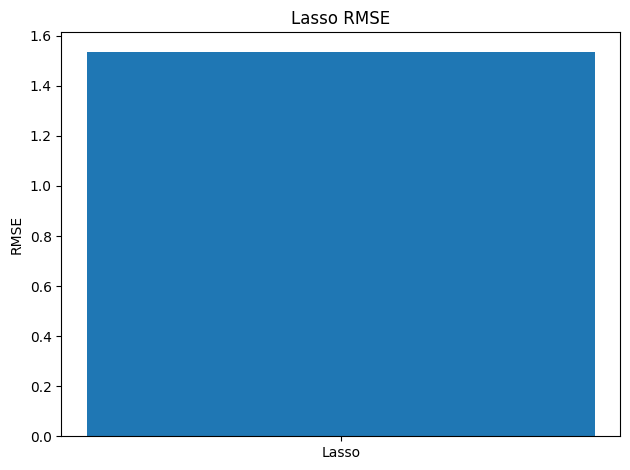

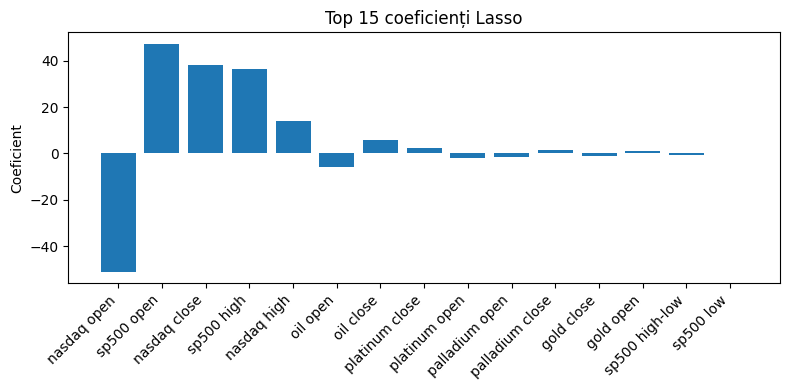

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

df = pd.read_csv("/content/financial_regression.csv")
df = df.dropna(subset=["sp500 close"])

target_col = "sp500 close"
y = df[target_col]
X = df.drop(columns=[target_col, "date"])
X = X.select_dtypes(include=["int64", "float64"])

#Împartire
n = len(df)
n_train = int(0.8 * n)
X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]

tscv = TimeSeriesSplit(n_splits=5)

#Lasso model si GridSearch
lasso_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000))
])

lasso_grid = GridSearchCV(
    lasso_pipeline,
    {"model__alpha": [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]},
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)
lasso_best = lasso_grid.best_estimator_
lasso_pred = lasso_best.predict(X_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print("LASSO REGRESSION")
print("Cel mai bun alpha:", lasso_grid.best_params_["model__alpha"])
print("RMSE:", lasso_rmse)

#Lasso coef
lasso_coefs = lasso_best.named_steps["model"].coef_
lasso_coef_df = pd.DataFrame({"feature": X.columns, "coef": lasso_coefs})
lasso_coef_df["abs_coef"] = lasso_coef_df["coef"].abs()
lasso_top15 = lasso_coef_df.sort_values("abs_coef", ascending=False).head(15)

# RMSE
plt.figure()
plt.bar(["Lasso"], [lasso_rmse])
plt.ylabel("RMSE")
plt.title("Lasso RMSE")
plt.tight_layout()
plt.show()

#15 coef
plt.figure(figsize=(8,4))
plt.bar(lasso_top15["feature"], lasso_top15["coef"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Coeficient")
plt.title("Top 15 coeficienti Lasso")
plt.tight_layout()
plt.show()
